In [1]:
import numpy as np
import lightkurve as lk
import matplotlib.pyplot as plt

/Users/aaryanthusoo/Desktop/UCL/Research/.venv/lib/python3.11/site-packages/lightkurve/prf/__init__.py:7: UserWarning: Warning: the tpfmodel submodule is not available without oktopus installed, which requires a current version of autograd. See #1452 for details.
  warnings.warn(


In [2]:
search_result = lk.search_lightcurve('KIC 2010607', author='Kepler')
#search_result

In [ ]:
lc = search_result[2].download()

In [ ]:
plt.plot(lc["flux"][300:500])
plt.show()

In [ ]:
def download_random_kepler_lc_stitched(kic_list, max_tries=10, min_points=1000):
    """
    Pick a random KIC, download ALL available Kepler light curves, stitch into one,
    and return (kic, stitched_lc).

    Parameters
    ----------
    kic_list : list[int]
        List of KIC IDs to sample from.
    max_tries : int
        How many random KICs to try before failing.
    min_points : int
        Minimum number of cadences required after cleaning.

    Returns
    -------
    kic : int
    lc  : lk.LightCurve
        Cleaned, stitched Kepler light curve.
    """
    for _ in range(max_tries):
        kic = int(np.random.choice(kic_list))
        srch = lk.search_lightcurve(f"KIC {kic}", mission="Kepler")

        if len(srch) == 0:
            continue

        try:
            lcc = srch.download_all()
            if lcc is None or len(lcc) == 0:
                continue

            lc = (lcc.stitch()
                    .remove_nans()
                    .remove_outliers(sigma=5)
                    .normalize())

            if len(lc.flux) >= min_points:
                return kic, lc

        except Exception:
            continue

    raise RuntimeError("Failed to download a usable stitched Kepler light curve.")

In [ ]:
kic, lc = download_random_kepler_lc_stitched([2010607])

In [ ]:
def extract_stellar_variability(lc, window_length=401):
    lc = lc.remove_nans().remove_outliers(sigma=5).normalize()  # important
    flat, trend = lc.flatten(window_length=window_length, return_trend=True)

    # stellar variability as fractional signal around 0
    stellar_var = (trend.flux / np.nanmedian(trend.flux)).value - 1.0
    return stellar_var, trend, flat


In [ ]:
stellar_var, trend, flat = extract_stellar_variability(lc)

In [ ]:
plt.figure(figsize=(12, 4))
plt.plot(np.arange(0, len(stellar_var)), stellar_var)
plt.title("Stellar variability (trend - 1)")
plt.show()

In [ ]:
plt.figure(figsize=(12, 4))
plt.plot()
plt.title("Stellar variability (trend - 1)")
plt.show()

In [1]:
from functions.noise_functions import *
import h5py

/Users/aaryanthusoo/Desktop/UCL/Research/.venv/lib/python3.11/site-packages/lightkurve/prf/__init__.py:7: UserWarning: Warning: the tpfmodel submodule is not available without oktopus installed, which requires a current version of autograd. See #1452 for details.
  warnings.warn(


In [10]:
kic_list = [
    757076, 892667, 1026032, 1161345, 1430163, 1571511, 1725815, 2010607,
    2162635, 2305372, 2571868, 2718678, 2987660, 3118883, 3241581,
    3544595, 3656476, 3733346, 3858884, 3964109, 4141376, 4247791, 4351319, 4484238, 4758595,
    4914423, 5094751, 5182131, 5356349, 5520878, 5701829, 5858947, 6032730, 6185476, 6278762,
    6442183, 6603624, 6763132, 6936115, 7269881, 7742534, 7871531,
    8179643, 8324268, 8462852, 8621637, 8751933, 9025370, 9159301,
    9532219, 9655114, 9775454, 9897820, 10135584, 10288502, 10417986, 10525077,
    10666592, 10797526, 11013201, 11253226, 11395018, 11717120,
    11820830, 11904151, 12009504, 12106934, 12258514, 12317678, 12644769, 12736056,
    12980372, 13073592, 13191135, 13299529, 13397662, 13480232, 13589264, 13672047]

In [11]:
def download_kepler_lc_stitched(srch, min_points=1000):

    lcc = srch.download_all()
    if lcc is None or len(lcc) == 0:
        raise RuntimeError("Failed to download a usable stitched Kepler light curve.")

    lc = (lcc.stitch()
            .remove_nans()
            .remove_outliers(sigma=5)
            .normalize())

    if len(lc.flux) >= min_points:
        return kic, lc
    return None

In [12]:
data_path = "/Users/aaryanthusoo/Desktop/UCL/Research/Work/data/kic_noise.h5"

with h5py.File(data_path, 'a') as h5:

    key_list = list(h5.keys())

    for kic in kic_list:
        if kic not in key_list:

            kic = str(kic)
            if kic not in h5:

                srch = lk.search_lightcurve(f"KIC {kic}", mission="Kepler")

                if len(srch) > 0:
                    kepler_result = download_kepler_lc_stitched(srch)

                    if kepler_result is not None:
                        lc = kepler_result[1]
                        data, _, _ = extract_stellar_variability(lc)

                        h5.create_dataset(str(kic), data=np.asarray(data))


Could not resolve "KIC 2854693" to a sky position.
Could not resolve "KIC 3445671" to a sky position.
Could not resolve "KIC 7096821" to a sky position.
Could not resolve "KIC 7434955" to a sky position.
Could not resolve "KIC 7591767" to a sky position.
Could not resolve "KIC 8890170" to a sky position.
Could not resolve "KIC 10012345" to a sky position.
Could not resolve "KIC 10905692" to a sky position.
Could not resolve "KIC 11145139" to a sky position.
Could not resolve "KIC 11613448" to a sky position.
Could not resolve "KIC 12980372" to a sky position.
Could not resolve "KIC 13073592" to a sky position.
Could not resolve "KIC 13191135" to a sky position.
Could not resolve "KIC 13299529" to a sky position.
Could not resolve "KIC 13397662" to a sky position.
Could not resolve "KIC 13480232" to a sky position.
Could not resolve "KIC 13589264" to a sky position.
Could not resolve "KIC 13672047" to a sky position.


In [13]:
def print_h5(name, obj):
    print(name, "|", type(obj))

with h5py.File(data_path, "r") as h5:
    print("\nFull file structure:")
    h5.visititems(print_h5)



Full file structure:
10135584 | <class 'h5py._hl.dataset.Dataset'>
1026032 | <class 'h5py._hl.dataset.Dataset'>
10288502 | <class 'h5py._hl.dataset.Dataset'>
10417986 | <class 'h5py._hl.dataset.Dataset'>
10525077 | <class 'h5py._hl.dataset.Dataset'>
10666592 | <class 'h5py._hl.dataset.Dataset'>
10797526 | <class 'h5py._hl.dataset.Dataset'>
11013201 | <class 'h5py._hl.dataset.Dataset'>
11253226 | <class 'h5py._hl.dataset.Dataset'>
11395018 | <class 'h5py._hl.dataset.Dataset'>
1161345 | <class 'h5py._hl.dataset.Dataset'>
11717120 | <class 'h5py._hl.dataset.Dataset'>
11820830 | <class 'h5py._hl.dataset.Dataset'>
11904151 | <class 'h5py._hl.dataset.Dataset'>
12009504 | <class 'h5py._hl.dataset.Dataset'>
12106934 | <class 'h5py._hl.dataset.Dataset'>
12258514 | <class 'h5py._hl.dataset.Dataset'>
12317678 | <class 'h5py._hl.dataset.Dataset'>
12644769 | <class 'h5py._hl.dataset.Dataset'>
12736056 | <class 'h5py._hl.dataset.Dataset'>
1430163 | <class 'h5py._hl.dataset.Dataset'>
1571511 | <clas

In [ ]:
kic = "757076"  # change as needed

with h5py.File(data_path, "r") as h5:
    if kic in h5:
        data = h5[kic][:]
        print("Shape:", data.shape)
        print("Dtype:", data.dtype)
        print("First 10 values:", data[:10])
    else:
        print("KIC not found in file.")


In [3]:
import h5py
from functions.h5_functions import *

data_path = "/Users/aaryanthusoo/Desktop/UCL/Research/Work/data/good_kic_noise.h5"

num_h5_keys(data_path)


28

## Doing it Properly This Time

In [2]:
import numpy as np
import lightkurve as lk
import matplotlib.pyplot as plt
from functions.noise_functions import *
from functions.h5_functions import *

import sys
from pathlib import Path

# Add project root to Python path
PROJECT_ROOT = Path.cwd().parent
sys.path.insert(0, str(PROJECT_ROOT))

from Work.LightCurve import LightCurve

h5_path = "/Users/aaryanthusoo/Desktop/UCL/Research/Work/data/good_kic_noise.h5"

In [3]:
kic_dict = load_kic_noise_dict(h5_path)
kic_list = list(kic_dict.keys())

Find the good light curves with a limit on how many times we check that curve as well as the needed percentage return

In [4]:
iteration_num = 10000
percent_good = 0.99

from scipy.signal import savgol_filter

In [5]:
std_vals, ptp_vals, mad_vals = [], [], []

for kic in kic_list:
    data = kic_dict[kic]

    std_vals.append(np.std(data))
    ptp_vals.append(np.ptp(data))

    smooth = savgol_filter(data, 21, 2)
    resid = data - smooth
    mad_vals.append(np.median(np.abs(np.diff(data) - np.median(np.diff(data)))))

In [6]:
std_low, std_high = np.percentile(std_vals, [10, 90])
ptp_low, ptp_high = np.percentile(ptp_vals, [10, 90])
low_mad, high_mad = np.percentile(mad_vals, [10, 90])

In [7]:
good, bad = [], []

for kic in kic_dict:
    data = kic_dict[kic]

    smooth = savgol_filter(data, 21, 2)
    resid = data - smooth

    noise_std = np.std(resid)
    noise_mad = np.median(np.abs(np.diff(data) - np.median(np.diff(data))))
    ptp_val = np.ptp(data)

    std_useful = std_low <= noise_std <= std_high
    mad_useful = low_mad <= noise_mad <= high_mad
    ptp_useful = ptp_low <= ptp_val <= ptp_high

    is_good = std_useful and ptp_useful and mad_useful

    if is_good:
        good.append(kic)
    else:
        bad.append(kic)

In [8]:
print(bad)

['1026032', '10288502', '10666592', '11820830', '12106934', '12644769', '1430163', '1571511', '2010607', '2162635', '2571868', '2718678', '2987660', '4351319', '4484238', '4758595', '5701829', '6185476', '7269881', '8324268', '8462852', '8751933', '892667', '9655114', '9775454', '9897820']


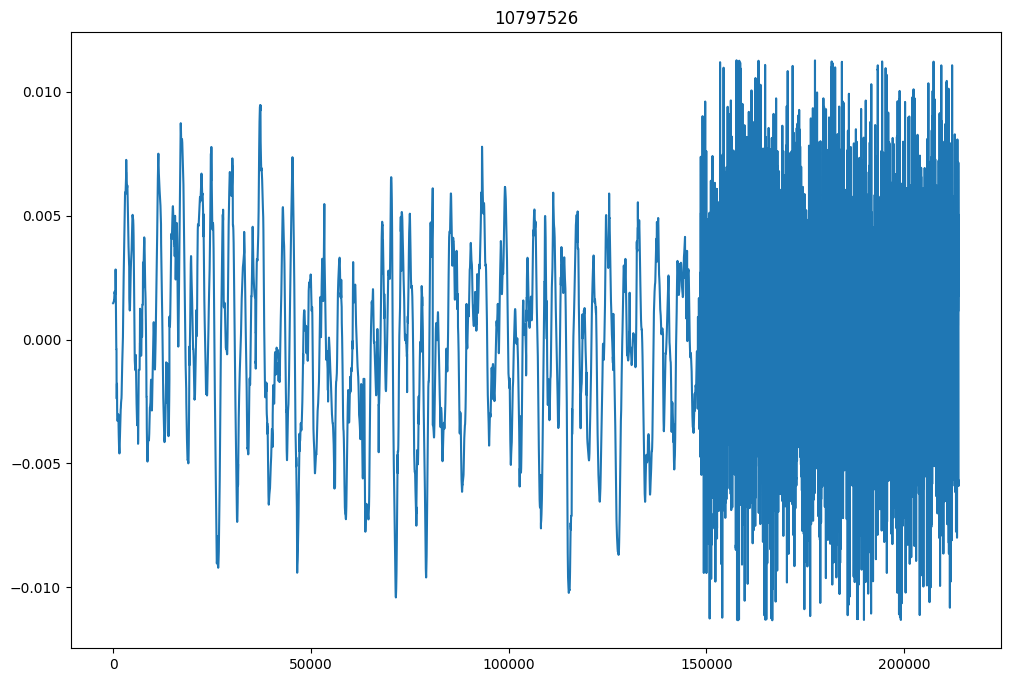

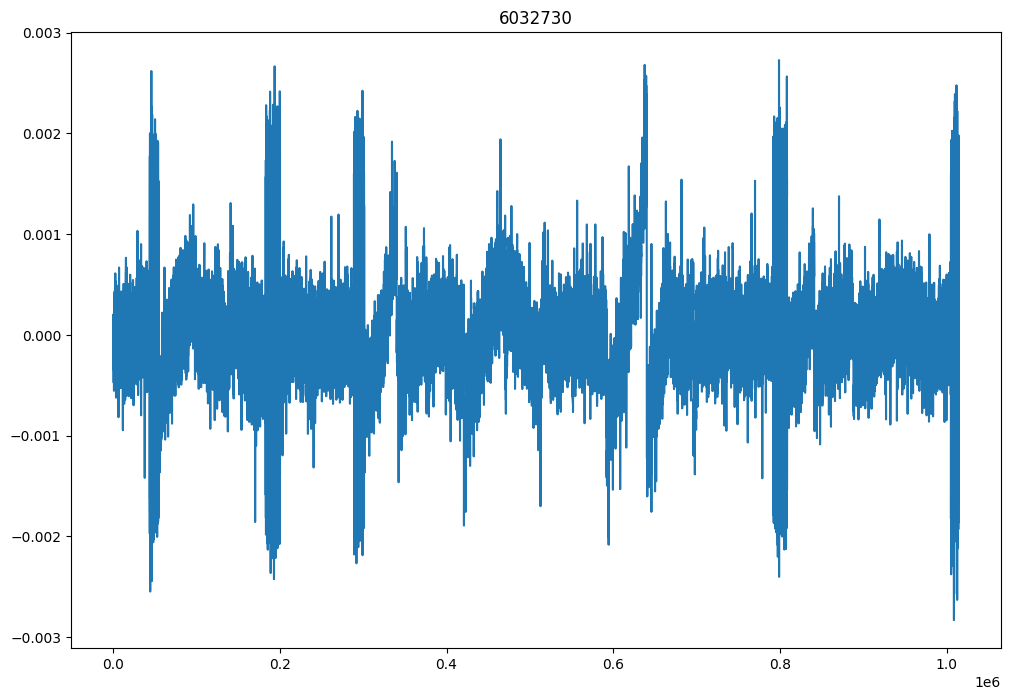

In [9]:
for g in good:
    plt.figure(figsize=(12, 8))
    lc = kic_dict[g]
    plt.plot(lc)
    plt.title(g)


Create a new dictionary and new h5 file with only the deemed good ones

In [37]:
new_kic_dict = {k: kic_dict[k] for k in good}

In [38]:
new_file_path = "/Users/aaryanthusoo/Desktop/UCL/Research/Work/data/even_better_kic_noise.h5"
create_h5_file(new_file_path, new_kic_dict)